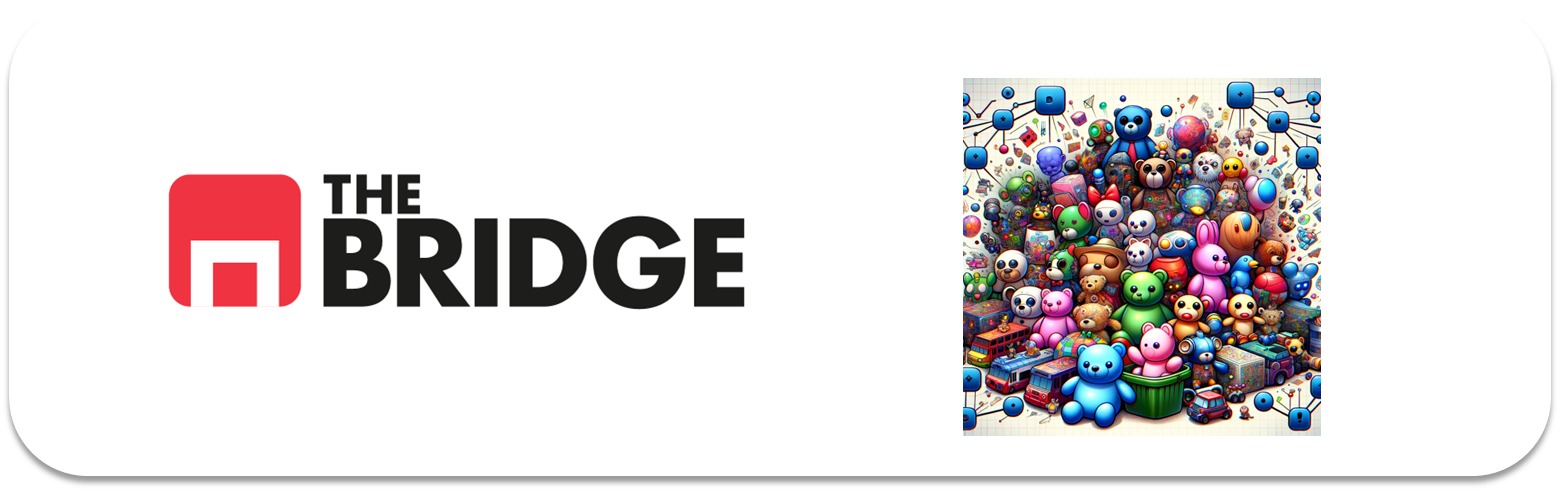

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
sns.set_style("whitegrid")

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [7]:
# Carga y exploración
df_drinks = pd.read_csv("data/empowering_drinks.csv", sep="|")
print(df_drinks.shape)
df_drinks.info()
df_drinks.describe().T
print("Nulos por columna:\n", df_drinks.isna().sum())

(153, 5)
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB
Nulos por columna:
 Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


In [8]:
df_drinks.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


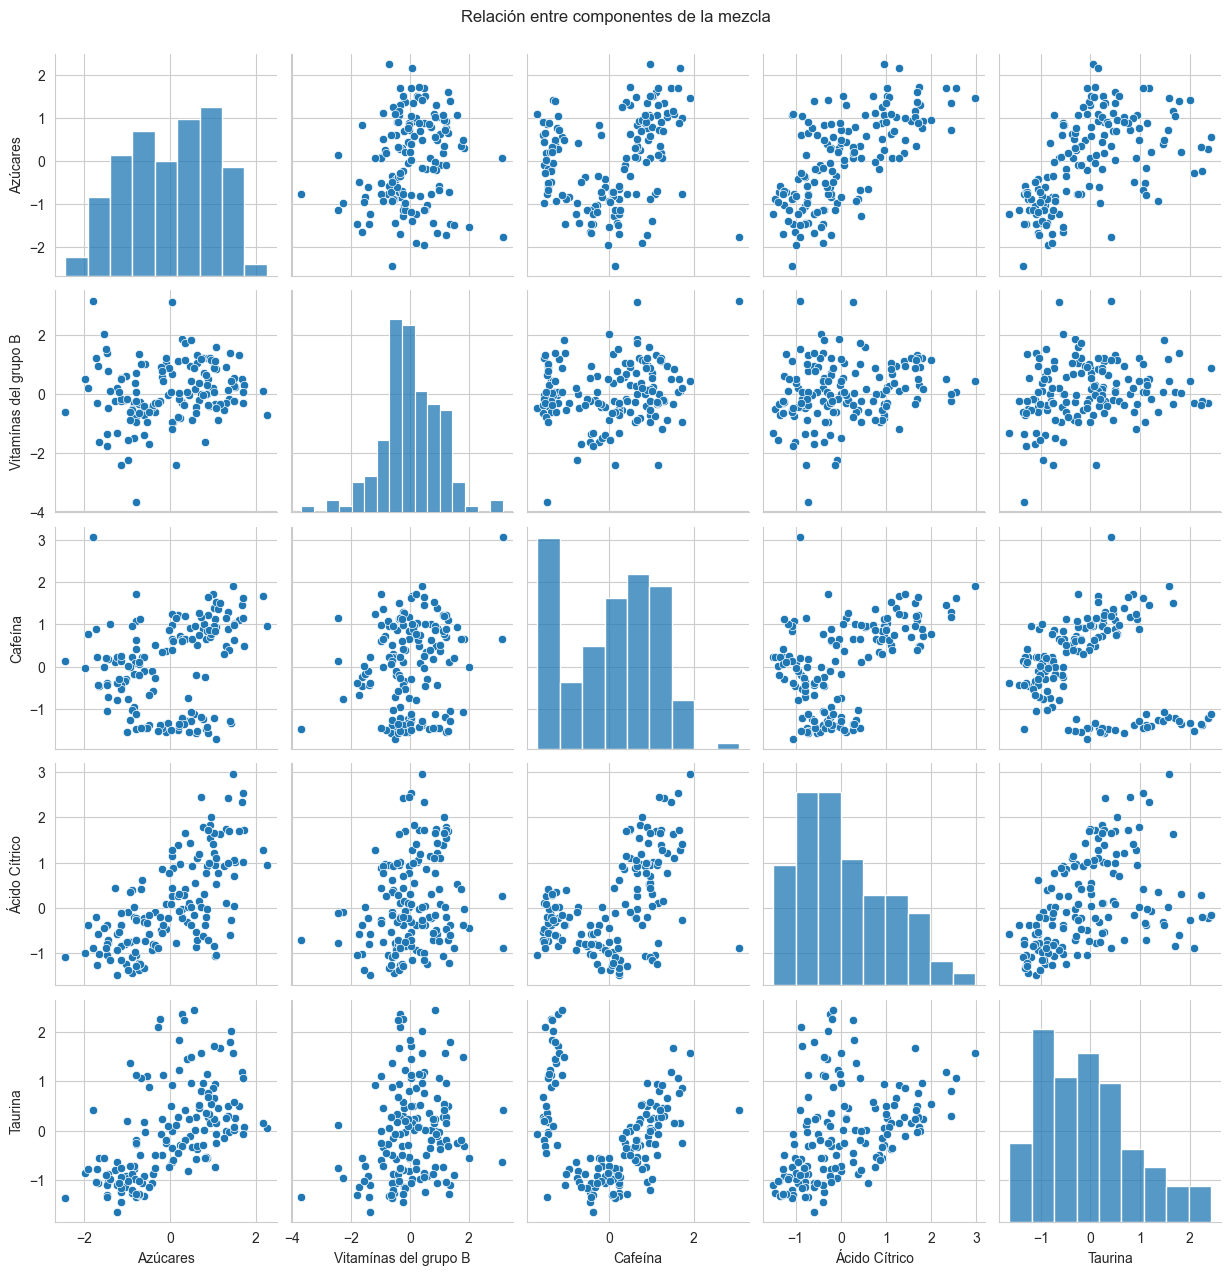

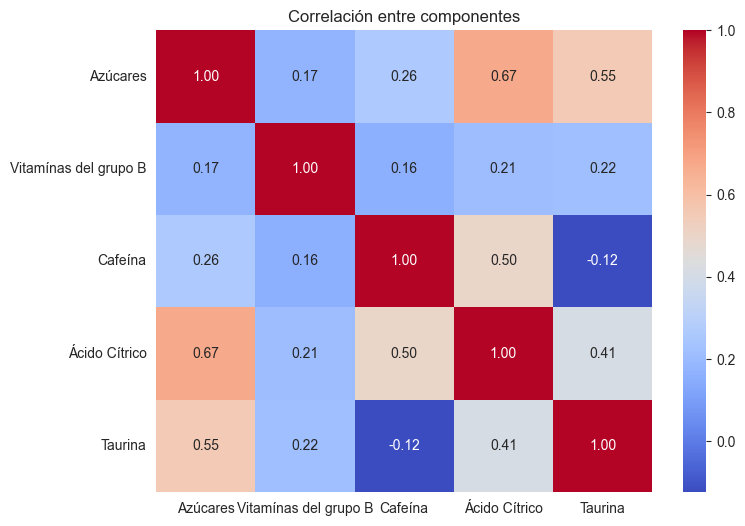

In [9]:
# Mini EDA: visualización por pares de variables
sns.pairplot(df_drinks)
plt.suptitle("Relación entre componentes de la mezcla", y=1.02)
plt.show()

# Matriz de correlación, para descartar variables redundantes
plt.figure(figsize=(8, 6))
sns.heatmap(df_drinks.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre componentes")
plt.show()

In [10]:
# Selección de features y escalado
# Sustituir 'features_seleccionadas' por las columnas elegidas tras el mini EDA
features_seleccionadas = df_drinks.columns.tolist() 

X = df_drinks[features_seleccionadas].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

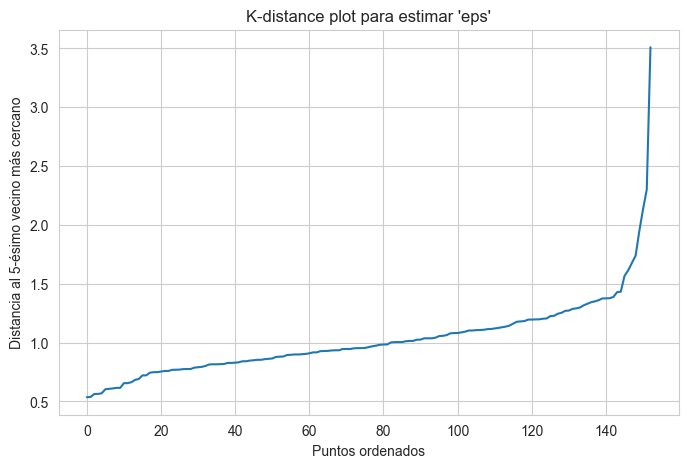

In [11]:
# DBSCAN: estimación de 'eps' con el k-distance plot
from sklearn.neighbors import NearestNeighbors

min_samples = 5  # punto de partida habitual: 2 * n_features, ajustar según resultados
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenamos las distancias al k-ésimo vecino, de menor a mayor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino más cercano")
plt.title("K-distance plot para estimar 'eps'")
plt.show()


In [12]:
# DBSCAN: prueba de varias combinaciones de hiperparámetros
resultados_dbscan = []

for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_samp in [3, 5, 8]:
        db = DBSCAN(eps=eps, min_samples=min_samp)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # La silueta solo tiene sentido si hay al menos 2 clusters reales
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else np.nan
        else:
            sil = np.nan

        resultados_dbscan.append((eps, min_samp, n_clusters, n_noise, sil))

df_resultados = pd.DataFrame(
    resultados_dbscan,
    columns=["eps", "min_samples", "n_clusters", "n_noise", "silhouette"]
)
print(df_resultados.sort_values("silhouette", ascending=False))

    eps  min_samples  n_clusters  n_noise  silhouette
5   0.8            8           2      124    0.741496
0   0.5            3           8      125    0.589455
8   1.0            8           3       66    0.515368
7   1.0            5           3       33    0.456290
6   1.0            3           4       19    0.383918
11  1.2            8           2       13    0.358062
4   0.8            5           7       85    0.317384
3   0.8            3           9       55    0.257766
1   0.5            5           0      153         NaN
2   0.5            8           0      153         NaN
9   1.2            3           1        7         NaN
10  1.2            5           1        7         NaN
12  1.5            3           1        4         NaN
13  1.5            5           1        4         NaN
14  1.5            8           1        4         NaN
15  2.0            3           1        1         NaN
16  2.0            5           1        1         NaN
17  2.0            8        

In [13]:
# 6Modelo DBSCAN final 
eps_final = 1.0       # << sustituir por el valor elegido tras el análisis
min_samples_final = 5  # << sustituir por el valor elegido tras el análisis

dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final)
labels_dbscan = dbscan_final.fit_predict(X_scaled)

df_drinks["cluster_dbscan"] = labels_dbscan
print(df_drinks["cluster_dbscan"].value_counts())

cluster_dbscan
 0    49
 1    41
-1    33
 2    30
Name: count, dtype: int64


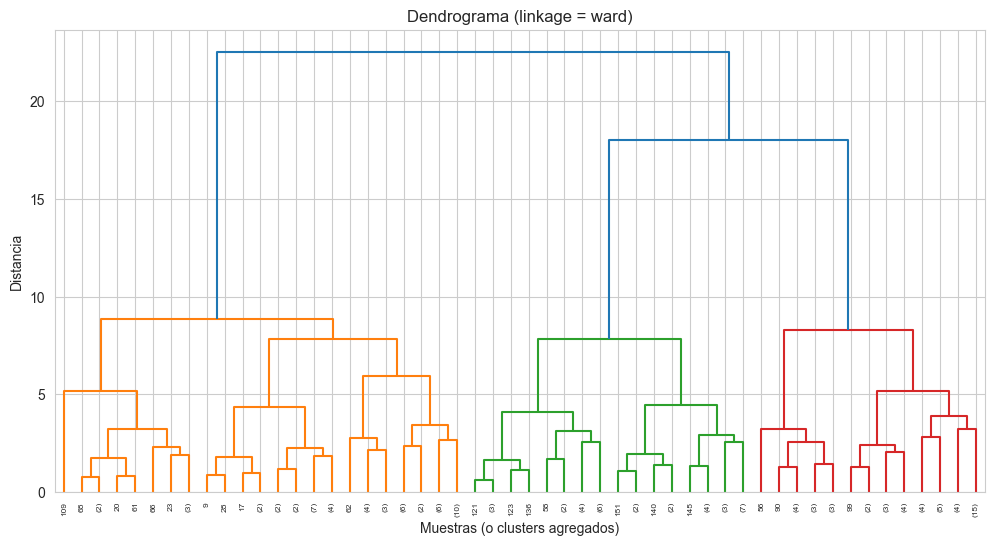

In [14]:
# Clustering Jerárquico: dendrograma
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrograma (linkage = ward)")
plt.xlabel("Muestras (o clusters agregados)")
plt.ylabel("Distancia")
plt.show()

In [15]:
# Selección del número de clusters jerárquicos (entre 3 y 5)
for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_k = agg.fit_predict(X_scaled)
    sil_k = silhouette_score(X_scaled, labels_k)
    print(f"k={k} -> silhouette = {sil_k:.3f}")

k=3 -> silhouette = 0.376
k=4 -> silhouette = 0.329
k=5 -> silhouette = 0.293


In [16]:
# Modelo Jerárquico final (sustituir k_final por el mejor valor obtenido)
k_final = 4  # << sustituir tras el análisis del paso anterior
agg_final = AgglomerativeClustering(n_clusters=k_final, linkage="ward")
labels_agg = agg_final.fit_predict(X_scaled)

df_drinks["cluster_jerarquico"] = labels_agg
print(df_drinks["cluster_jerarquico"].value_counts())

cluster_jerarquico
1    52
0    50
2    40
3    11
Name: count, dtype: int64


In [18]:
# Comparación entre ambos modelos
comparacion = pd.crosstab(df_drinks["cluster_dbscan"], df_drinks["cluster_jerarquico"])
print(comparacion)

cluster_jerarquico   0   1   2  3
cluster_dbscan                   
-1                  10  10   9  4
 0                   0  42   0  7
 1                  40   0   1  0
 2                   0   0  30  0


## Interpretaciones

DBSCAN identifica tres grupos principales de bebidas y además detecta 33 observaciones como ruido o casos atípicos. Esto puede ser interesante para los químicos porque esas mezclas podrían representar formulaciones poco comunes o experimentos con características muy diferentes al resto.

La principal ventaja de DBSCAN en este problema es precisamente su capacidad para detectar outliers sin necesidad de asignarlos obligatoriamente a un grupo.

El clustering jerárquico consigue segmentar todas las observaciones, sin dejar elementos como ruido. Además, el dendrograma permite visualizar qué grupos son más parecidos entre sí y cómo se van formando progresivamente las agrupaciones.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Carga y exploración
df_new_exp = pd.read_csv("data/new_experiments.csv", sep="|")
print(df_new_exp.shape)
df_new_exp.info()
df_new_exp.describe().T
print("Nulos por columna:\n", df_new_exp.isna().sum())

(6, 5)
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               6 non-null      float64
 1   Vitamínas del grupo B  6 non-null      float64
 2   Cafeína                6 non-null      float64
 3   Ácido Cítrico          6 non-null      float64
 4   Taurina                6 non-null      float64
dtypes: float64(5)
memory usage: 372.0 bytes
Nulos por columna:
 Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


In [21]:
df_new_exp.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [23]:
X_new_scaled = scaler.transform(df_new_exp[features_seleccionadas])


knn_segmentador = KNeighborsClassifier(n_neighbors=5)
knn_segmentador.fit(X_scaled, labels_agg)

# Predicción del segmento para los nuevos experimentos
nuevos_segmentos = knn_segmentador.predict(X_new_scaled)
df_new_exp["cluster_predicho"] = nuevos_segmentos

print(df_new_exp[["cluster_predicho"]].value_counts())

cluster_predicho
0                   2
2                   2
1                   1
3                   1
Name: count, dtype: int64


### 

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.